In [2]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import math

CONTEXT_WIDTH = 3
DEVICE = "cpu"
SEED = 42
RANDOM_GENERATOR = torch.Generator(device=DEVICE).manual_seed(SEED)

NAMES = [name.strip() for name in open("names.txt", "r").readlines()]

def name_to_tensor(name):
    return torch.tensor([0]+[1 + ord(c) - ord("a") for c in name]+[0])
def tensor_to_name(tensor):
    return "".join([chr(c + ord("a")-1) for c in tensor[1:-1]])

def sliding_mean(x: torch.Tensor, window: int) -> torch.Tensor:
    x = x.float()
    prefix = torch.cat((x.new_zeros(1), x.cumsum(dim=0)))
    return (prefix[window:] - prefix[:-window]) / window

def plotStat(stat, starting_at=0, smoothing=1):
    plt.plot(
        [starting_at+smoothing-1+x for x in range(len(stat)-starting_at-smoothing+1)], 
        sliding_mean(torch.tensor(stat[starting_at:]), smoothing))


# Prepare test sets

def prepareTestSets(names):
    X = []
    Y = []
    for name in names:
        t = name_to_tensor(name)
        x = [0] * CONTEXT_WIDTH

        for i in range(0, len(t)-1):
            x = x[1:] + [t[i].item()]
            X.append(x)
            Y.append(t[i+1].item())
    return (torch.tensor(X, device=DEVICE), torch.tensor(Y, device=DEVICE))

random.seed(SEED)
random.shuffle(NAMES)

names80p = int(len(NAMES)*0.8)
names90p = int(len(NAMES)*0.9)

inputX_train, inputY_train = prepareTestSets(NAMES[:names80p])
inputX_val, inputY_val = prepareTestSets(NAMES[names80p:names90p])
inputX_test, inputY_test = prepareTestSets(NAMES[names90p:])

0 3.8154077529907227
5000 2.2761881351470947
10000 2.174511671066284
15000 2.133232593536377
20000 2.0821664333343506
25000 2.014838218688965
30000 2.0958919525146484
35000 2.266113758087158
40000 1.956709384918213
45000 2.2218222618103027
50000 1.9457085132598877
55000 1.9116735458374023
60000 2.0693984031677246
65000 2.013787031173706
70000 2.010985851287842
75000 1.9854152202606201
80000 2.2396254539489746
85000 2.0521419048309326
90000 2.195956230163574
95000 1.9542157649993896
0 2.2885727882385254
5000 1.9851258993148804
10000 2.0218429565429688
15000 2.024059772491455
20000 1.9269134998321533
25000 2.2187557220458984
30000 2.02797269821167
35000 1.985827922821045
40000 2.066993474960327
45000 2.1277899742126465
50000 2.028358221054077
55000 2.0119271278381348
60000 2.0284900665283203
65000 1.7614644765853882
70000 2.065350294113159
75000 1.9960896968841553
80000 2.0120866298675537
85000 2.1897592544555664
90000 2.063478946685791
95000 1.9861520528793335


(2.091970682144165, 2.0322160720825195)

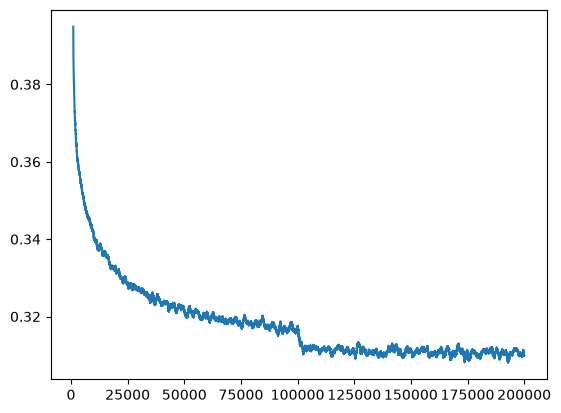

In [9]:

class EmbeddingLayer:
    def __init__(self, num_embeddings, embedding_dim, context_width, init_scale=1.0):
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.context_width = context_width
        self.embedding = torch.randn(num_embeddings, embedding_dim)
        for p in self.parameters():
            p.requires_grad = True

    def __call__(self, x, training=False):
        return self.embedding[x].view(-1, self.embedding_dim * self.context_width)

    def parameters(self):
        return [self.embedding]

class LinearLayer:
    def __init__(self, in_features, out_features, bias=True, init_scale=1.0):
        self.in_features = in_features
        self.out_features = out_features
        self.bias = None if not bias else torch.randn(out_features) * 0.01
        self.weight = torch.randn(out_features, in_features) * init_scale * (1.0/math.sqrt(in_features + 1e-8))
        if bias:
            self.bias = torch.randn(out_features) * 0.01
        for p in self.parameters():
            p.requires_grad = True

    def __call__(self, x, training=False):
        self.out = x @ self.weight.T + (self.bias if self.bias is not None else 0)
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:
    def __init__(self, num_features, eps=1e-5, momentum=0.01):
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)
        self.weight = torch.ones(num_features)
        self.bias = torch.zeros(num_features)
        for p in self.parameters():
            p.requires_grad = True

    def __call__(self, x, training=False):
        mean = self.running_mean
        var = self.running_var

        if training:
            mean = x.mean(dim=0, keepdim=True)
            var = x.var(dim=0, keepdim=True)

        R = (x - mean)/torch.sqrt(var + self.eps)
        self.out = R * self.weight + self.bias

        if training:        
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * mean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * var

        return self.out 

    def parameters(self):
        return [self.weight, self.bias]

class TanhLayer:
    def __init__(self):
        pass

    def __call__(self, x, training=False):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class CrossEntropyLoss:
    def __init__(self):
        pass

    def __call__(self, x, y, training=False):
        return F.cross_entropy(x, y)

    def parameters(self):
        return []


class Model:
    def __init__(self, layers):
        self.layers = layers
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def layersWeights(self):
        res = []
        for layer in self.layers:
            if isinstance(layer, LinearLayer):
                res.append(layer.weight)
        return res

    def __call__(self, inputs, outputs=None, training=False):
        R = inputs
        for layer in self.layers[:-1]:
            if isinstance(layer, CrossEntropyLoss):
                R = layer(R, outputs, training)
            else:
                R = layer(R, training)

        if (not training and isinstance(self.layers[-1], CrossEntropyLoss)):
            return R.softmax(dim=1)
        elif isinstance(self.layers[-1], CrossEntropyLoss): 
            R = self.layers[-1](R, outputs, training)
        else:
            R = self.layers[-1](R, training)

        return R
        
stats_losses = []
stats_updates = []

def doTraining(
    NN,
    trainX,
    trainY, 
    iterations = 1000, 
    batchSize = 32, 
    learningRate = 0.1, 
    printEvery = -1):

    for iteration in range(iterations):
        idx = torch.randint(0, len(trainX), (batchSize,), device=DEVICE, generator=RANDOM_GENERATOR)

        for param in NN.parameters():
            param.grad = None

        R = NN(trainX[idx], trainY[idx], training=True)
        R.backward()
        with torch.no_grad():
            for param in NN.parameters():
                param -= learningRate * param.grad
        if printEvery!=-1 and iteration%printEvery == 0: print(iteration, R.item())
        # Update stats 
        stats_losses.append(R.log10().item())
        stats_updates.append(
            [
                ((learningRate * param.grad.std())/param.data.std()).log10()
                for param in NN.parameters()
            ])

    loss_train = NN(trainX, trainY, training=True).item()

    for param in NN.parameters():
            param.grad = None
    loss_test = NN(inputX_test, inputY_test, training=True)
    for layer in NN.layers:
        if hasattr(layer, "out"):
            layer.out.retain_grad()
    loss_test.backward()
    return (loss_test.item(), loss_train)


NN = Model(layers=[
    EmbeddingLayer(27, 10, CONTEXT_WIDTH),
    LinearLayer(10 * CONTEXT_WIDTH, 200, bias=False, init_scale=5.0/3.0),
    BatchNorm1d(200),
    TanhLayer(),
    LinearLayer(200, 27, init_scale=5.0/3.0),
    CrossEntropyLoss()
])


# 2.091707944869995
'''
NN = Model(layers=[
    EmbeddingLayer(27, 16, CONTEXT_WIDTH),
    LinearLayer(16 * CONTEXT_WIDTH, 120, init_scale=5.0/3.0, bias=False),
    BatchNorm1d(120),
    TanhLayer(),
    LinearLayer(120, 120, init_scale=5.0/3.0, bias=False),
    BatchNorm1d(120),
    TanhLayer(),
    LinearLayer(120, 27, init_scale=5.0/3.0),
    CrossEntropyLoss()
])
'''

r = doTraining(
    NN,
    inputX_train,
    inputY_train,
    iterations=100000,
    batchSize=128,
    learningRate=0.1,
    printEvery=5000
)
r = doTraining(
    NN,
    inputX_train,
    inputY_train,
    iterations=100000,
    batchSize=128,
    learningRate=0.01,
    printEvery=5000
)
plotStat(stats_losses, starting_at=0, smoothing=1000)
r

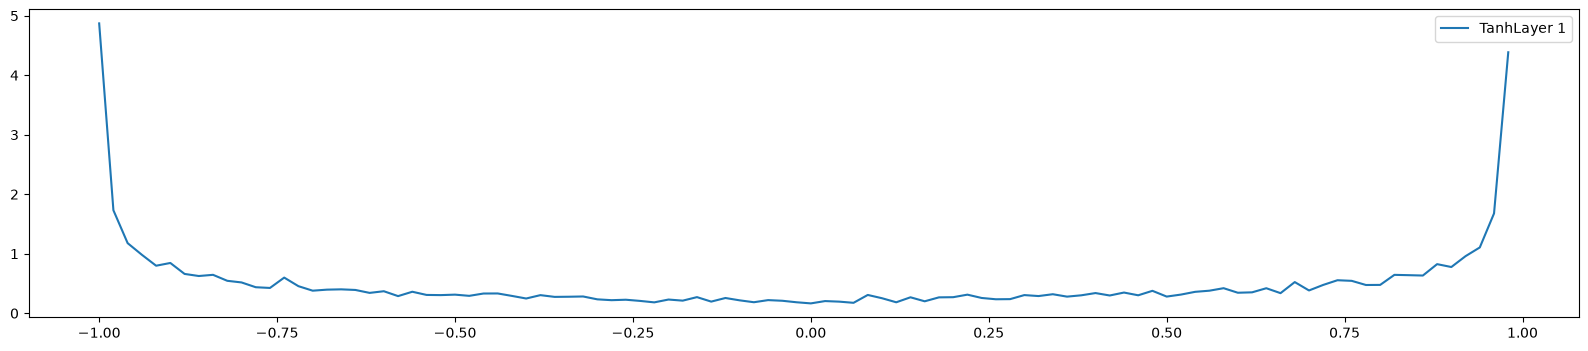

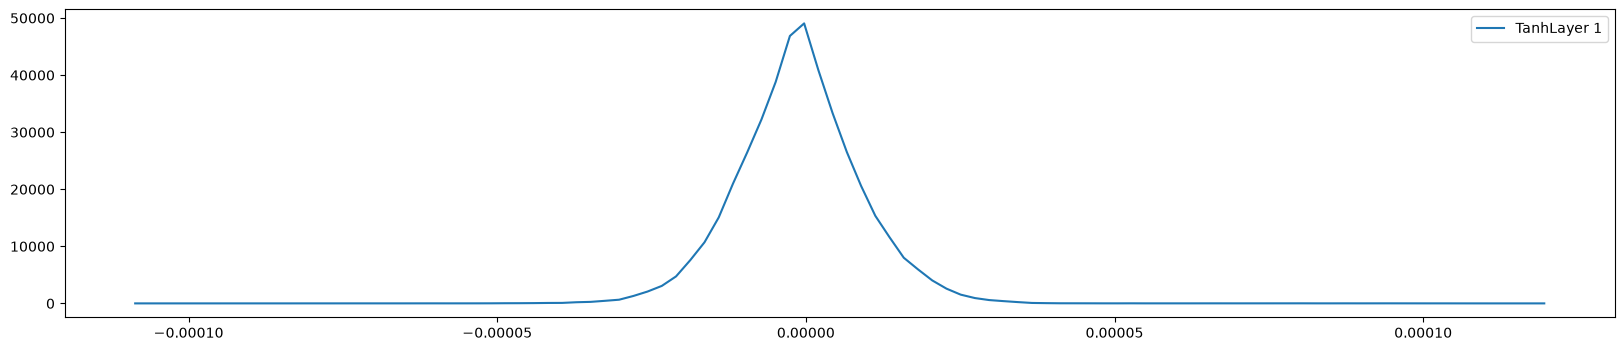

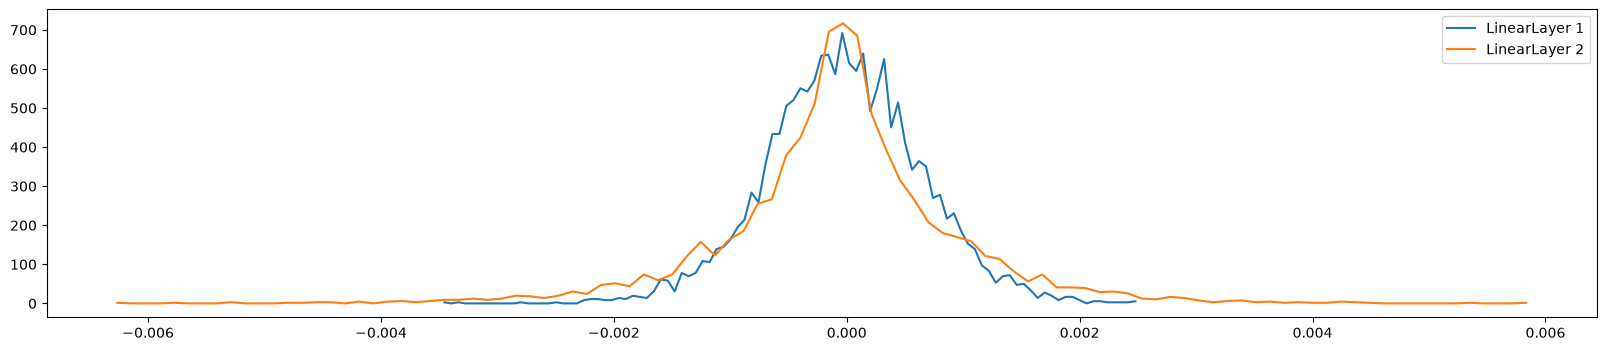

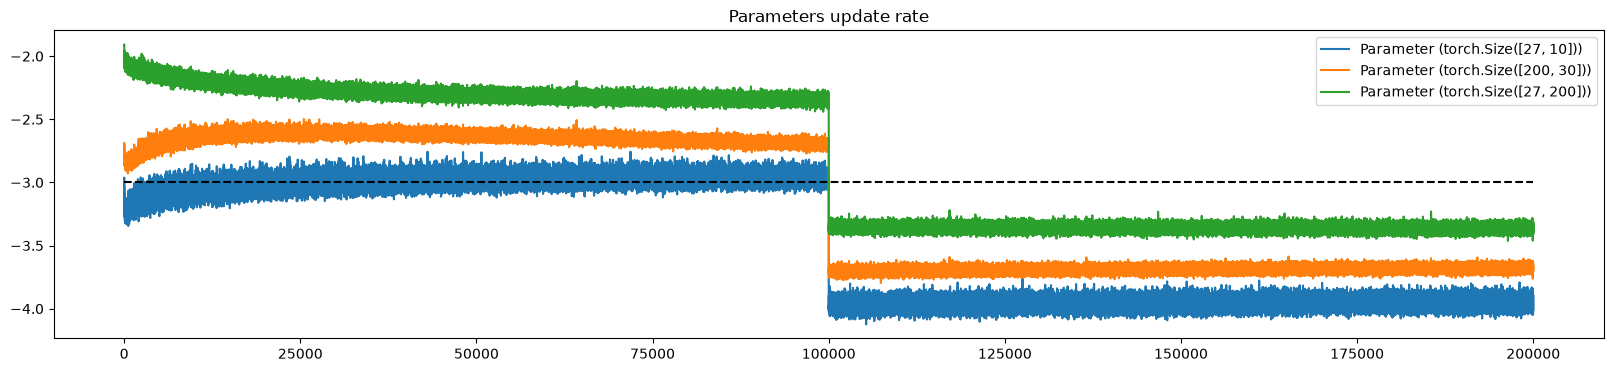

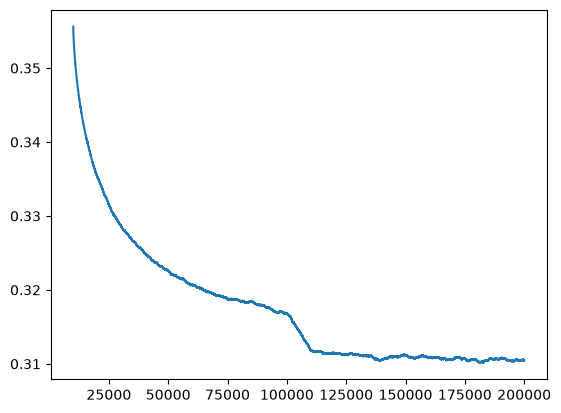

In [11]:
# Activations
plt.figure(figsize=(20, 4))
legends = []
layer_n = 1
for layer in NN.layers:
    if isinstance(layer, TanhLayer):
        t = layer.out
        hy,hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"TanhLayer {layer_n}")
        layer_n += 1
plt.legend(legends)
plt.show()

# Grads for activations
plt.figure(figsize=(20, 4))
legends = []
layer_n = 1
for layer in NN.layers:
    if isinstance(layer, TanhLayer):
        t = layer.out.grad
        hy,hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"TanhLayer {layer_n}")
        layer_n += 1
plt.legend(legends)
plt.show()

# Parameters grads
plt.figure(figsize=(20, 4))
legends = []
layer_n = 1
for layer in NN.layers:
    if isinstance(layer, LinearLayer):
        t = layer.parameters()[0].grad
        hy,hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"LinearLayer {layer_n}")
        layer_n += 1
plt.legend(legends)
plt.show()

# Parameters update rate
plt.figure(figsize=(20, 4))
legends = []
for i, param in enumerate(NN.parameters()):
    if param.ndim == 2:
        plt.plot([stats_updates[j][i] for j in range(len(stats_updates))])
        legends.append(f"Parameter ({param.shape})")
plt.plot([0,len(stats_updates)], [-3, -3], 'k--')
plt.title("Parameters update rate")
plt.legend(legends)
plt.show()

plotStat(stats_losses, starting_at=0, smoothing=10000)



In [12]:

def genWord():
    res = [0]*CONTEXT_WIDTH
    
    while True:
        b = NN(res[-CONTEXT_WIDTH:]).multinomial(num_samples=1, replacement=True).item()
        res.append(b)
        if b == 0:
            break;

    return tensor_to_name(res[CONTEXT_WIDTH-1:])

print("loss:", NN(inputX_test, inputY_test, training=True).item())

for i in range(20):
    print(genWord())

# Leun    

loss: 2.091970682144165
kelinth
alon
sel
chesco
stephariane
rebi
belley
irrah
baylyn
paxton
akmyn
hil
nesar
garilynn
dan
queyon
sterleyberley
malijahzen
delina
judaymar
